In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)

In [4]:
def gibbs_sampler(mus, sigmas, n_iter=5000):
    samples = []
    y = mus[1]
    for _ in range(n_iter):
        x = p_x_given_y(y, mus, sigmas)
        y = p_y_given_x(x, mus, sigmas)
        samples.append([x, y])
    return samples

In [5]:
def p_x_given_y(y, mus, sigmas):
    mu = mus[0] + sigmas[1, 0] / sigmas[0, 0] * (y - mus[1])
    sigma = sigmas[0, 0] - sigmas[1, 0] / sigmas[1, 1] * sigmas[1, 0]
    return np.random.normal(mu, sigma)

def p_y_given_x(x, mus, sigmas):
    mu = mus[1] + sigmas[0, 1] / sigmas[1, 1] * (x - mus[0])
    sigma = sigmas[1, 1] - sigmas[0, 1] / sigmas[0, 0] * sigmas[0, 1]
    return np.random.normal(mu, sigma)

In [6]:
mus = np.asarray([5, 5])
sigmas = np.asarray([[1, .9], [.9, 1]])

samples = gibbs_sampler(mus, sigmas); samples[:5]

[[5.094375689072134, 5.058667902942396],
 [5.175861934887288, 5.447651414116084],
 [5.358397131507042, 5.278071396535993],
 [5.550314691828798, 5.641095821184971],
 [5.487786105738833, 5.542093903446283]]

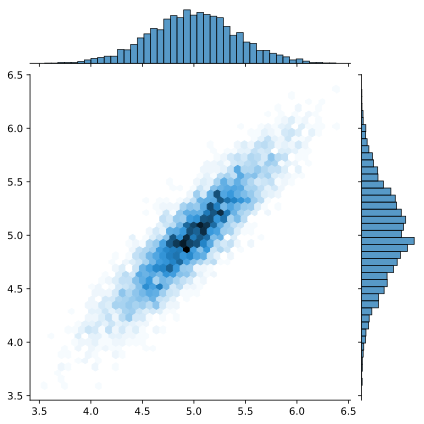

In [8]:
burn = 100
x, y = zip(*samples[burn:])
sns.jointplot(x=x, y=y, kind='hex')
plt.show()

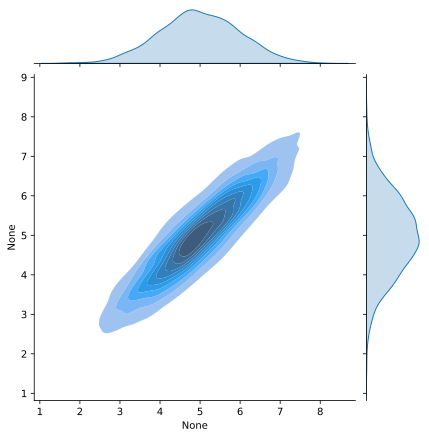

In [12]:
samples = np.random.multivariate_normal(mus, sigmas, 5000)

sns.jointplot(x=samples[:, 0], y=samples[:, 1], kind='kde', fill=True)
plt.show()